In [27]:
# import libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader,TensorDataset

In [28]:
# import dataset
import pandas as pd
iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')

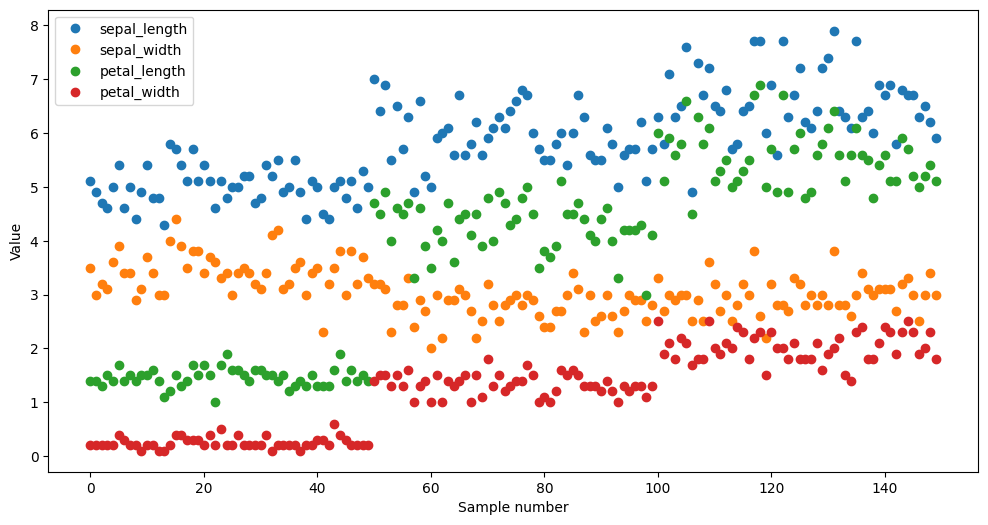

In [29]:
# plot the data
iris.plot(marker='o',linestyle='none',figsize=(12,6))
plt.xlabel('Sample number')
plt.ylabel('Value')
plt.show()
     

####   ------------------------------- < NOTE ABOUT THIS CELL!!! > ---------------------------------------   ####
#                                                                                                               #
# The code here is intentionally commented out. We're going to use this in the lecture "The importance of       #
# data standardization" in the next section. If you're not doing that lecture, leave this commented! Thanks!    #
#                                                                                                               #
####   -------------------------------  --------------------------------------   ####


# # z-score the data
# import scipy.stats as stats
# cols2zscore = iris.keys()
# cols2zscore = cols2zscore.drop('species')
# iris[cols2zscore] = iris[cols2zscore].apply(stats.zscore)

# iris.plot(marker='o',linestyle='none',figsize=(12,6))
# plt.xlabel('Sample number')
# plt.ylabel('Value')
# plt.show()
     


In [30]:
data=torch.tensor(iris[iris.columns[0:4]].values).float()

labels=torch.zeros(len(data),dtype=torch.long)

labels[iris.species=='setosa'] = 1
# labels[iris.species=='virginica'] = 2 

torch.unique(labels, return_counts=True)

(tensor([0, 1]), tensor([100,  50]))

In [31]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels,test_size=.2)

train_data = TensorDataset(train_data,train_labels)
test_data = TensorDataset(test_data,test_labels)



In [32]:
def createANewModel():

    ANNiris = nn.Sequential(
        nn.Linear(4,64),
        nn.ReLU(),
        nn.Linear(64,64),
        nn.ReLU(),
        nn.Linear(64,2)
    )

    lossfun = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(ANNiris.parameters(),lr=.0001)

    return ANNiris, lossfun, optimizer

In [33]:
# train the model
# global parameter
numepochs = 500

def trainTheModel(model,lossfun,optimizer):

  # initialize accuracies as empties
  trainAcc = []
  testAcc  = []
  losses   = []

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = model(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # compute training accuracy just for this batch
      batchAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1) == y).float()).item() )
      batchLoss.append( loss.item() )
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )
    losses.append( np.mean(batchLoss) )

    # test accuracy
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    predlabels = torch.argmax( model(X),axis=1 )
    testAcc.append( 100*torch.mean((predlabels == y).float()).item() )

  # function output
  return trainAcc,testAcc,losses

     

In [34]:
# # create a model
# ANNiris,lossfun,optimizer = createANewModel()

# # train the model
# trainAcc,testAcc,losses = trainTheModel()

powers = np.arange(1,7)


# batch_sizes = np.linspace(2,50,6)
results = np.zeros((len(powers),2))

for i, b_size in enumerate(powers):
    batchsize = int(2**b_size)
    train_loader = DataLoader(train_data,batch_size=batchsize, shuffle=True,drop_last=True)
    test_loader = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

    ANNiris,lossfun,optimizer = createANewModel()
    trainAcc, testAcc, losses = trainTheModel(ANNiris,lossfun,optimizer)

    results[i,0] = np.mean(trainAcc)
    results[i,1] = np.mean(testAcc)




# # plot the results



# ax[0].plot(losses,'k^-')
# ax[0].set_ylabel('Loss')
# ax[0].set_xlabel('Epochs')
# ax[0].set_title('Losses with minibatch size=' + str(batchsize))

# ax[1].plot(trainAcc,'ro-')
# ax[1].plot(testAcc,'bs-')
# ax[1].set_title('Accuracy with minibatch size=' + str(batchsize))
# ax[1].set_xlabel('Epochs')
# ax[1].set_ylabel('Accuracy (%)')
# ax[1].legend(['Train','Test'])
# ax[1].set_ylim([27,103])





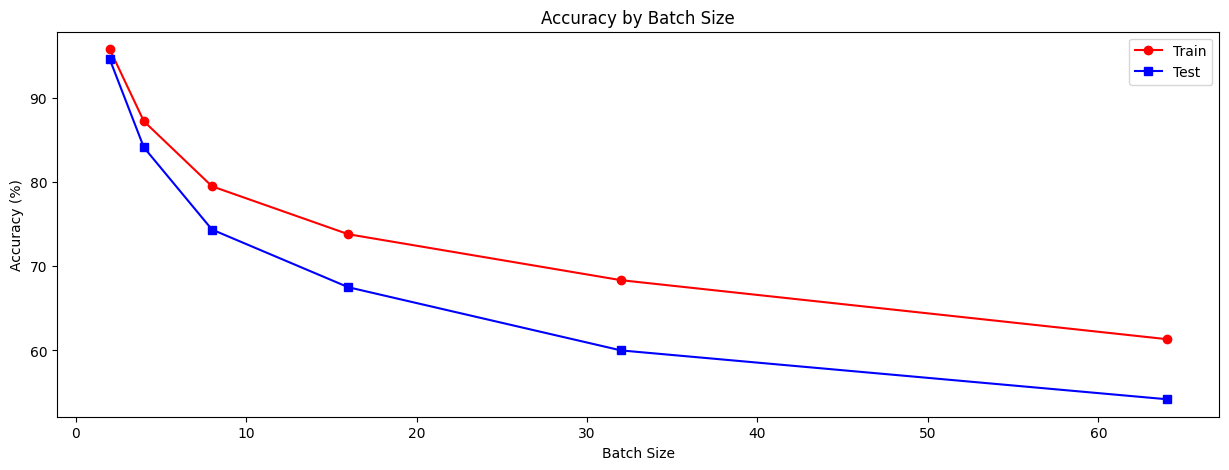

In [35]:
fig,ax = plt.subplots(1,figsize=(15,5))
ax.plot(2**powers,results[:,0],'ro-')
ax.plot(2**powers,results[:,1], 'bs-')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Batch Size')
ax.legend(['Train','Test'])

plt.show()